Importing libraries and Modells 

In [ ]:
import sys
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Importera din befintliga preprocessing-modul
sys.path.append("..")
from backend.app.ml.preprocessing import prepare_data

<module 'backend.app.ml.preprocessing' from 'c:\\Users\\jarll\\Desktop\\repos\\Predictor\\models\\..\\backend\\app\\ml\\preprocessing.py'>

Import CSV file and print the data

In [ ]:
FILE_PATH = "../dataset/all_zones_complete_2025.csv"

# 1. Läs in och kör pipelinen (den skapar hour, month, day_of_week, is_weekend)
df_raw = pd.read_csv(FILE_PATH)
df = prepare_data(df_raw, include_lags=False)

# Verifiera att kalender-features finns
calendar_cols = ["hour", "day_of_week", "month", "is_weekend"]
print(f"Inläst data: {df.shape[0]} rader.")
print(f"Kalender-kolumner: {calendar_cols}")
display(df[["timestamp_local", "zone"] + calendar_cols].head(3))

Inläst: 35040 rader, 14 kolumner


In [ ]:
# Features för klustringen (spotpris + väderfaktorer)
FEATURES = ["spot_price_eur_mwh", "wind_speed_kmh", "temperature_c"]

# Rensa eventuella saknade värden
df_clean = df.dropna(subset=FEATURES).copy().reset_index(drop=True)

X = df_clean[FEATURES]



Rader efter pipeline och dropna: 34944, Feature: 6


In [ ]:
# Standardisera värdena
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Träningsdata klar: {X_scaled.shape[0]} rader fördelat på SE1–SE4.")

In [42]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Skala data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Träna K-Means med exakt 3 kluster enligt kravspecen
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean["cluster_raw"] = kmeans.fit_predict(X_scaled)

# 3. Mappa kluster 0, 1, 2 till Lågpris, Medelpris, Högpris baserat på snittpris
price_order = (
    df_clean.groupby("cluster_raw")["spot_price_eur_mwh"].mean().sort_values().index
)

cluster_label_mapping = {
    price_order[0]: "Lågpris",
    price_order[1]: "Medelpris",
    price_order[2]: "Högpris",
}

df_clean["price_cluster"] = df_clean["cluster_raw"].map(cluster_label_mapping)
df_clean["cluster"] = df_clean["price_cluster"]  # För bakåtkompatibilitet

Träna modellen 

In [35]:
FINAL_K = elbow_k  # eller sätt manuellt t.ex. 4

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(X_scaled)

# 1. Klusterprofiler (medelvärden för features)
print("--- Klusterprofiler (Medelvärden) ---")
display(df_clean.groupby("cluster")[FEATURES].mean().round(2))

# 2. Korsanalys: Hur många timmar spenderar respektive zon i respektive kluster?
print("\n--- Fördelning av kluster per zon (procentuell) ---")
zone_cluster_distribution = (
    pd.crosstab(df_clean["zone"], df_clean["cluster"], normalize="index") * 100
).round(1)
display(zone_cluster_distribution)

--- Klusterprofiler (Medelvärden) ---


,spot_price_eur_mwh,temperature_c,wind_speed_kmh,hour,month,price_lag_24
cluster,,,,,,
0,20.59,0.34,13.98,10.65,2.48,20.55
1,18.69,13.49,15.14,16.55,7.63,20.05
2,25.09,8.22,11.95,4.95,8.75,23.57
3,104.47,5.09,11.77,14.21,6.92,103.46



--- Fördelning av kluster per zon (procentuell) ---


cluster,0,1,2,3
zone,,,,
SE1,32.6,32.6,28.9,6.0
SE2,30.4,33.3,30.6,5.7
SE3,20.7,30.0,27.8,21.6
SE4,15.8,28.4,22.9,32.9


Spara modellen

In [40]:
from pathlib import Path
import joblib

# 1. Definiera kataloger
model_dir = Path("../models_bin")
dataset_dir = Path("../dataset")

model_dir.mkdir(parents=True, exist_ok=True)
dataset_dir.mkdir(parents=True, exist_ok=True)

# 2. Spara artefakterna i models_bin med Path-syntax (/)
model_path = model_dir / "kmeans_zone_model.pkl"
scaler_path = model_dir / "scaler_zone.pkl"

joblib.dump(kmeans, model_path)
joblib.dump(scaler, scaler_path)

# 3. Spara det berikade datasetet i dataset-mappen
output_dataset = dataset_dir / "all_zones_clustered_long_2025.csv"
df_clean.to_csv(output_dataset, index=False)

print("Sparat:")
print(f" - Modell:  {model_path}")
print(f" - Scaler:  {scaler_path}")
print(f" - Dataset: {output_dataset}")

Sparat:
 - Modell:  ..\models_bin\kmeans_zone_model.pkl
 - Scaler:  ..\models_bin\scaler_zone.pkl
 - Dataset: ..\dataset\all_zones_clustered_long_2025.csv


<Figure size 1000x550 with 0 Axes>

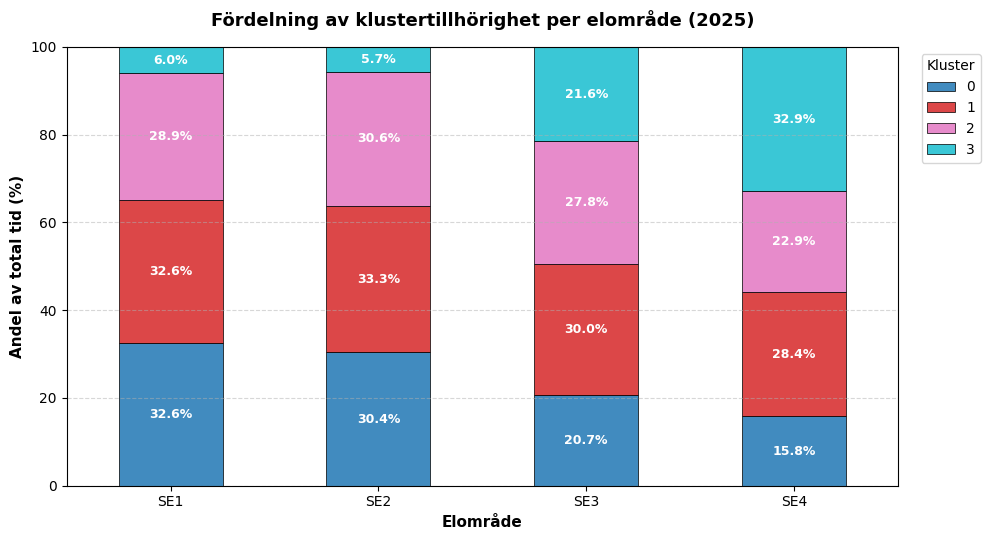

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Beräkna procentuell fördelning per zon och kluster
zone_dist = pd.crosstab(df_clean["zone"], df_clean["cluster"], normalize="index") * 100

# 2. Plotta stapeldiagrammet
plt.figure(figsize=(10, 5.5))
ax = zone_dist.plot(
    kind="bar",
    stacked=True,
    colormap="tab10",
    figsize=(10, 5.5),
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
)

plt.title(
    "Fördelning av klustertillhörighet per elområde (2025)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Elområde", fontsize=11, fontweight="bold")
plt.ylabel("Andel av total tid (%)", fontsize=11, fontweight="bold")
plt.xticks(rotation=0, fontsize=10)
plt.ylim(0, 100)
plt.legend(title="Kluster", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Lägg till procentetiketter inuti staplarna (för segment > 5%)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5.0:
        x, y = p.get_xy()
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="white",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()